In [2]:
print("Define Wirecell Fiducial Volume")

# read input and create arrays
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import sys
import os
from scipy.spatial import KDTree

Define Wirecell Fiducial Volume


In [3]:
# Lets define all initial variables we want to use to read all files
first_event               = 0     # first event number in the list of all events
last_event                = 16    # last event number in the list of all events
evt                       = 16     # event number for showing an example

SBNDCODE_VERSION          = "v10_06_00"   # Use the latest version available
PROCESS                   = "nu_spill"    # options: "nu_spill", "cosmic_spill"
apa                       = "APA0"        # options: "APA0", "APA1"

OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/out/")
SUBDIR="24308437_0" # TODO: we need to find a way of not hardcoding this

print("SBNDCODE_VERSION:", SBNDCODE_VERSION)
print("PROCESS:", PROCESS)
print("apa:", apa)
print("OUTDIR", OUTDIR)
print("SUBDIR", SUBDIR)
print("First event", first_event)
print("Last event", last_event)


SBNDCODE_VERSION: v10_06_00
PROCESS: nu_spill
apa: APA0
OUTDIR /exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/out
SUBDIR 24308437_0
First event 0
Last event 16


In [4]:
# Create output sub-directories

OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"
else:
  print("\n Incorrect PROCESS.\n\n")

In [5]:
# skip notebook if missing truth files
SKIP_NOTEBOOK = False   # TODO: what does this do?

print ("Checking for required truth files...")

# helper function to skip notebook execution
def skip_if_needed():
    if globals().get("SKIP_NOTEBOOK", False):
        return True
    return False

Checking for required truth files...


In [6]:
# Definition to read true and predicted coordinates

def read_true_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    _e = np.loadtxt(files[5])
    _t = np.loadtxt(files[6])
    return _x, _y, _z, _id, _q, _e, _t

def read_pred_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    return _x, _y, _z, _id, _q 


In [7]:
# Definition to point to input text file for each event

NEWOUTDIR     = OUTDIR/"xyz-coordinates"  
def files_true_pred(evt):
    fx_true_apa0  = NEWOUTDIR / str(evt) / "x_truth_apa0.txt"
    fy_true_apa0  = NEWOUTDIR / str(evt) / "y_truth_apa0.txt"
    fz_true_apa0  = NEWOUTDIR / str(evt) / "z_truth_apa0.txt"
    fq_true_apa0  = NEWOUTDIR / str(evt) / "charge_truth_apa0.txt"
    fid_true_apa0 = NEWOUTDIR / str(evt) / "clusterid_truth_apa0.txt"
    fe_true_apa0  = NEWOUTDIR / str(evt) / "energy_truth_apa0.txt"
    ft_true_apa0  = NEWOUTDIR / str(evt) / "time_truth_apa0.txt"

    fx_true_apa1  = NEWOUTDIR / str(evt) / "x_truth_apa1.txt"
    fy_true_apa1  = NEWOUTDIR / str(evt) / "y_truth_apa1.txt"
    fz_true_apa1  = NEWOUTDIR / str(evt) / "z_truth_apa1.txt"
    fq_true_apa1  = NEWOUTDIR / str(evt) / "charge_truth_apa1.txt"
    fid_true_apa1 = NEWOUTDIR / str(evt) / "clusterid_truth_apa1.txt"
    fe_true_apa1  = NEWOUTDIR / str(evt) / "energy_truth_apa1.txt"
    ft_true_apa1  = NEWOUTDIR / str(evt) / "time_truth_apa1.txt"

    fx_pred_apa0  = NEWOUTDIR / str(evt) / "x_clustering_apa0.txt"
    fy_pred_apa0  = NEWOUTDIR / str(evt) / "y_clustering_apa0.txt"
    fz_pred_apa0  = NEWOUTDIR / str(evt) / "z_clustering_apa0.txt"
    fq_pred_apa0  = NEWOUTDIR / str(evt) / "charge_clustering_apa0.txt"
    fid_pred_apa0 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa0.txt"

    fx_pred_apa1  = NEWOUTDIR / str(evt) / "x_clustering_apa1.txt"
    fy_pred_apa1  = NEWOUTDIR / str(evt) / "y_clustering_apa1.txt"
    fz_pred_apa1  = NEWOUTDIR / str(evt) / "z_clustering_apa1.txt"
    fq_pred_apa1  = NEWOUTDIR / str(evt) / "charge_clustering_apa1.txt"
    fid_pred_apa1 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa1.txt"

    # check for missing or empty truth files
    if apa =='APA0':
        if not fx_true_apa0.exists() or os.stat(fx_true_apa0).st_size <= 1:
            print(f"{fx_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa0.exists() or os.stat(fy_true_apa0).st_size<= 1:
            print(f"{fy_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa0.exists() or os.stat(fz_true_apa0).st_size <= 1:
            print(f"{fz_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa0.exists() or os.stat(fx_pred_apa0).st_size <= 1:
            print(f"{fx_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa0.exists() or os.stat(fy_pred_apa0).st_size<= 1:
            print(f"{fy_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa0.exists() or os.stat(fz_pred_apa0).st_size <= 1:
            print(f"{fz_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
    elif apa =='APA1':
        if not fx_true_apa1.exists() or os.stat(fx_true_apa1).st_size <= 1:
            print(f"{fx_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa1.exists() or os.stat(fy_true_apa1).st_size <= 1:
            print(f"{fy_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa1.exists() or os.stat(fz_true_apa1).st_size <= 1:
            print(f"{fz_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa1.exists() or os.stat(fx_pred_apa1).st_size <= 1:
            print(f"{fx_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa1.exists() or os.stat(fy_pred_apa1).st_size<= 1:
            print(f"{fy_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa1.exists() or os.stat(fz_pred_apa1).st_size <= 1:
            print(f"{fz_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        else:
            print("Incorrect apa.")
        
    # Skip if truth files not found
    if skip_if_needed():
        print("Skipping this cell.")
    else:
        
        # group files for loading
        true_files_apa0 = [fx_true_apa0, fy_true_apa0, fz_true_apa0, fid_true_apa0, fq_true_apa0, fe_true_apa0, ft_true_apa0]  # Replace with file names
        true_files_apa1 = [fx_true_apa1, fy_true_apa1, fz_true_apa1, fid_true_apa1, fq_true_apa1, fe_true_apa1, ft_true_apa1]  # Replace with file names
        pred_files_apa0 = [fx_pred_apa0, fy_pred_apa0, fz_pred_apa0, fid_pred_apa0, fq_pred_apa0]
        pred_files_apa1 = [fx_pred_apa1, fy_pred_apa1, fz_pred_apa1, fid_pred_apa1, fq_pred_apa1]

        if apa =='APA0':
            true_files = true_files_apa0
            reco_files = pred_files_apa0
        else:
            true_files = true_files_apa1
            reco_files = pred_files_apa1
    return true_files, reco_files


In [8]:
# Now we get the variable values

# loop over many events to read all variables for all events
all_events_true_x = []
all_events_true_y = []
all_events_true_z = []
all_events_true_id = []
all_events_true_q = []
all_events_true_e = []
all_events_true_t = []

all_events_reco_x = []
all_events_reco_y = []
all_events_reco_z = []
all_events_reco_id = []
all_events_reco_q = []

# Lets read folders of all events
for e in range(first_event, last_event+1):
  print("Event: ", e)

  true_files, pred_files = files_true_pred(e)

  # Define placeholders
  x_true = y_true = z_true = id_true = q_true = e_true = t_true = None
  x_pred = y_pred = z_pred = id_pred = q_pred = None

  # Load the true and predicted coordinates
  if apa =='APA0':
    x_true_apa0, y_true_apa0, z_true_apa0, id_true_apa0, q_true_apa0, e_true_apa0 , t_true_apa0 = read_true_coordinates(true_files)
    x_pred_apa0, y_pred_apa0, z_pred_apa0, id_pred_apa0, q_pred_apa0                            = read_pred_coordinates(pred_files)
    
    x_true  = x_true_apa0
    y_true  = y_true_apa0
    z_true  = z_true_apa0
    id_true = id_true_apa0
    q_true  = q_true_apa0
    e_true  = e_true_apa0
    t_true  = t_true_apa0

    x_pred  = x_pred_apa0
    y_pred  = y_pred_apa0
    z_pred  = z_pred_apa0
    id_pred = id_pred_apa0
    q_pred  = q_pred_apa0

  elif apa =='APA1':
    x_true_apa1, y_true_apa1, z_true_apa1, id_true_apa1, q_true_apa1, e_true_apa1, t_true_apa1= read_true_coordinates(true_files)
    x_pred_apa1, y_pred_apa1, z_pred_apa1, id_pred_apa1, q_pred_apa1                          = read_pred_coordinates(pred_files)
    
    x_true  = x_true_apa1
    y_true  = y_true_apa1
    z_true  = z_true_apa1
    id_true = id_true_apa1
    q_true  = q_true_apa1   
    e_true  = e_true_apa1
    t_true  = t_true_apa1

    x_pred  = x_pred_apa1
    y_pred  = y_pred_apa1
    z_pred  = z_pred_apa1
    id_pred = id_pred_apa1
    q_pred  = q_pred_apa1

  else:
    print("Incorrect apa.")


  all_events_true_x.append(x_true)
  all_events_true_y.append(y_true)
  all_events_true_z.append(z_true)
  all_events_true_id.append(id_true)
  all_events_true_q.append(q_true)
  all_events_true_e.append(e_true)
  all_events_true_t.append(t_true)

  all_events_reco_x.append(x_pred)
  all_events_reco_y.append(y_pred)
  all_events_reco_z.append(z_pred)
  all_events_reco_id.append(id_pred)
  all_events_reco_q.append(q_pred)

# conver all points into one array
all_events_true_x_points = np.concatenate(all_events_true_x)
all_events_reco_x_points = np.concatenate(all_events_reco_x)

all_events_true_y_points = np.concatenate(all_events_true_y)
all_events_reco_y_points = np.concatenate(all_events_reco_y)

all_events_true_z_points = np.concatenate(all_events_true_z)
all_events_reco_z_points = np.concatenate(all_events_reco_z)


Event:  0
Event:  1
Event:  2
Event:  3
Event:  4
Event:  5
Event:  6
Event:  7
Event:  8
Event:  9
Event:  10
Event:  11
Event:  12
Event:  13
Event:  14
Event:  15
Event:  16


In [9]:
# Get the true and reco points
print("True x points: size", len(all_events_true_x_points), ", shape: ", all_events_true_x_points.shape)
print("Reco x points: size", len(all_events_reco_x_points), ", shape: ", all_events_reco_x_points.shape)


True x points: size 639710 , shape:  (639710,)
Reco x points: size 268200 , shape:  (268200,)


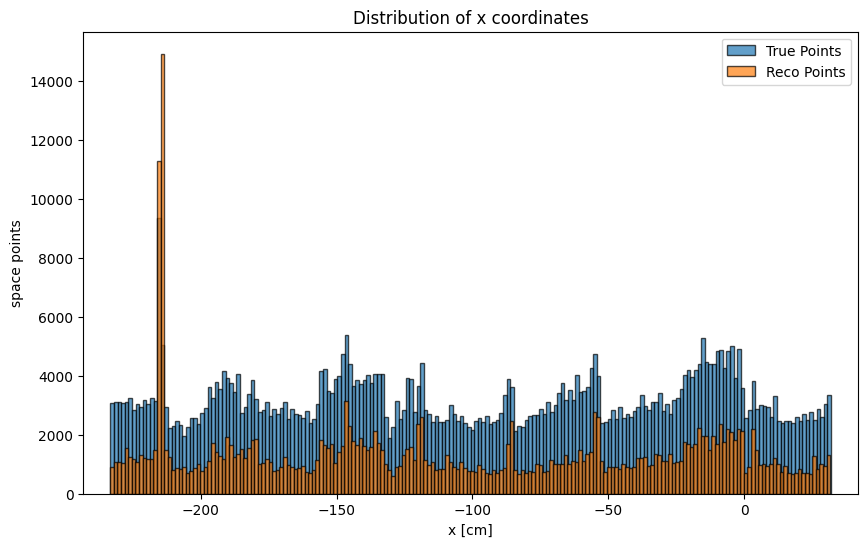

xmin: xmax
true:  -233.2 31.9
reco: -233.25, 31.638


In [10]:
# lets plot x true and reco points
plt.figure(figsize=(10, 6))
plt.hist(all_events_true_x_points, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(all_events_reco_x_points, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(all_events_true_x_points.min() - 10, all_events_true_x_points.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("x [cm]")
plt.ylabel("space points")
plt.title("Distribution of x coordinates")
plt.legend()
plt.show(block=False)

print("xmin: xmax")
true_x_min = all_events_true_x_points.min()
true_x_max = all_events_true_x_points.max()
reco_x_min = all_events_reco_x_points.min()
reco_x_max = all_events_reco_x_points.max()

print(f"true: ", true_x_min, true_x_max)
print(f"reco: {reco_x_min:2.5g}, {reco_x_max:2.5g}")

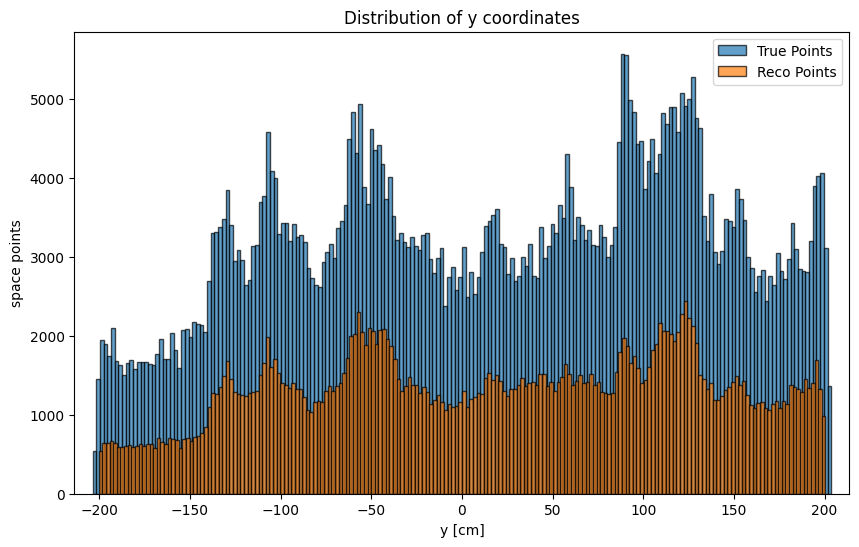

ymin: ymax
true:  -203.7 203.7
reco: -200.31, 200.49


In [11]:
# lets plot y true and reco points
plt.figure(figsize=(10, 6))
plt.hist(all_events_true_y_points, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(all_events_reco_y_points, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(all_events_true_y_points.min() - 10, all_events_true_y_points.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("y [cm]")
plt.ylabel("space points")
plt.title("Distribution of y coordinates")
plt.legend()
plt.show(block=False)

print("ymin: ymax")
true_y_min = all_events_true_y_points.min()
true_y_max = all_events_true_y_points.max()
reco_y_min = all_events_reco_y_points.min()
reco_y_max = all_events_reco_y_points.max()

print(f"true: ", true_y_min, true_y_max)
print(f"reco: {reco_y_min:2.5g}, {reco_y_max:2.5g}")

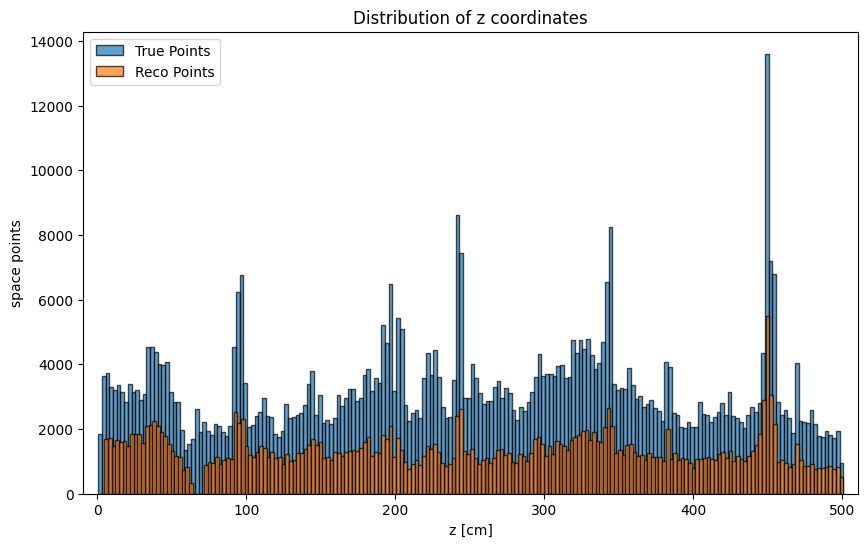

zmin: zmax
true:  0.6 500.6
reco: 4.6997, 500.6


In [12]:
# lets plot y true and reco points

# shift reco z points by 0.5 cm to match true points but make a copy of reco z points to not change original reco z points
all_events_reco_z_points_shifted = all_events_reco_z_points + 0.5

plt.figure(figsize=(10, 6))
plt.hist(all_events_true_z_points, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(all_events_reco_z_points_shifted, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(all_events_true_z_points.min() - 10, all_events_true_z_points.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("z [cm]")
plt.ylabel("space points")
plt.title("Distribution of z coordinates")
plt.legend()
plt.show(block=False)

print("zmin: zmax")
true_z_min = all_events_true_z_points.min()
true_z_max = all_events_true_z_points.max()
reco_z_min = all_events_reco_z_points_shifted.min()
reco_z_max = all_events_reco_z_points_shifted.max()

print(f"true: ", true_z_min, true_z_max)
print(f"reco: {reco_z_min:2.5g}, {reco_z_max:2.5g}")

In [13]:
# Get true and reco clusters for event number evt
print(f"Getting true and reco clusters for event {evt}...")

# Extract data for the specific event (offset by first_event since arrays start from first_event)
evt = 3
event_index = evt

evt_true_x = all_events_true_x[event_index]
evt_true_y = all_events_true_y[event_index]
evt_true_z = all_events_true_z[event_index]
evt_true_id = all_events_true_id[event_index]
evt_true_q = all_events_true_q[event_index]
evt_true_e = all_events_true_e[event_index]
evt_true_t = all_events_true_t[event_index]

evt_reco_x = all_events_reco_x[event_index]
evt_reco_y = all_events_reco_y[event_index]
evt_reco_z = all_events_reco_z[event_index]
evt_reco_id = all_events_reco_id[event_index]
evt_reco_q = all_events_reco_q[event_index]

print(f"Event {evt} - True clusters: {len(evt_true_x)} points, {len(np.unique(evt_true_id))} unique cluster IDs")
print(f"Event {evt} - Reco clusters: {len(evt_reco_x)} points, {len(np.unique(evt_reco_id))} unique cluster IDs")

Getting true and reco clusters for event 16...
Event 3 - True clusters: 25934 points, 43 unique cluster IDs
Event 3 - Reco clusters: 7296 points, 12 unique cluster IDs


/tmp/ipykernel_1128741/3092962034.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


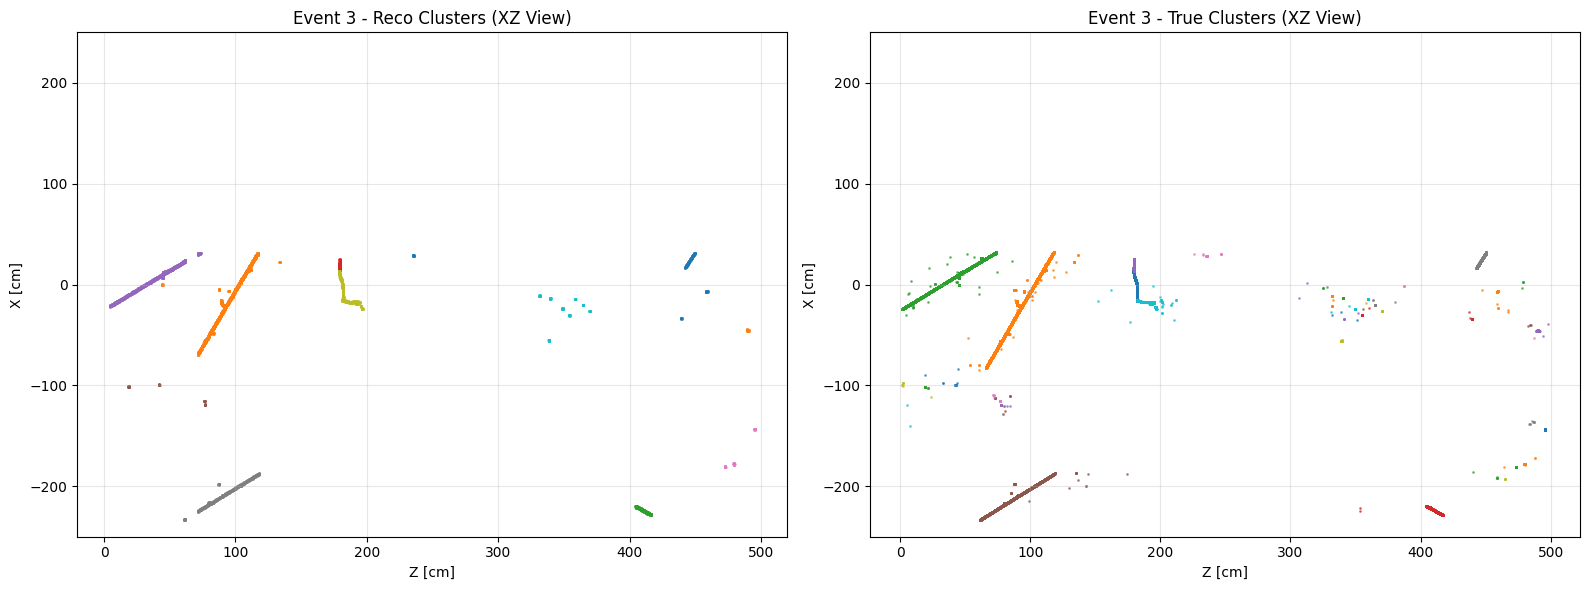

Reco plot: 12 clusters
True plot: 43 clusters


In [14]:
# Draw all clusters in XZ view - Reco (left) and True (right)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get unique cluster IDs
unique_true_ids = np.unique(evt_true_id)
unique_reco_ids = np.unique(evt_reco_id)

# Create a colormap for consistent coloring
cmap = plt.cm.get_cmap('tab20')

# Left plot: Reco clusters
ax_reco = axes[0]
for cluster_id in unique_reco_ids:
    mask = evt_reco_id == cluster_id
    ax_reco.scatter(evt_reco_z[mask], evt_reco_x[mask], 
                    s=1, alpha=0.6, label=f'Cluster {int(cluster_id)}')
ax_reco.set_xlabel('Z [cm]')
ax_reco.set_ylabel('X [cm]')
ax_reco.set_ylim(-250, 250)
ax_reco.set_title(f'Event {evt} - Reco Clusters (XZ View)')
ax_reco.grid(True, alpha=0.3)

# Right plot: True clusters
ax_true = axes[1]
for cluster_id in unique_true_ids:
    mask = evt_true_id == cluster_id
    ax_true.scatter(evt_true_z[mask], evt_true_x[mask], 
                    s=1, alpha=0.6, label=f'Cluster {int(cluster_id)}')
ax_true.set_xlabel('Z [cm]')
ax_true.set_ylabel('X [cm]')
ax_true.set_ylim(-250, 250)
ax_true.set_title(f'Event {evt} - True Clusters (XZ View)')
ax_true.grid(True, alpha=0.3)

plt.tight_layout()
plt.show(block=False)

print(f"Reco plot: {len(unique_reco_ids)} clusters")
print(f"True plot: {len(unique_true_ids)} clusters")

In [15]:
# Define Wirecell Fiducial Volume boundaries
def define_fiducial_volume():
    """Define the Wirecell fiducial volume boundaries."""
    fiducial_volume = {
        'X_min': -250.0,
        'X_max': 250.0,
        'Y_min': -203.3,
        'Y_max': 200.5,
        'Z_min': 4.7,
        'Z_max': 500.6
    }
    return fiducial_volume

def is_inside_fiducial_volume(x, y, z, fiducial_volume):
    """Check if points are inside the fiducial volume."""
    inside = (
        (x >= fiducial_volume['X_min']) & (x <= fiducial_volume['X_max']) &
        (y >= fiducial_volume['Y_min']) & (y <= fiducial_volume['Y_max']) &
        (z >= fiducial_volume['Z_min']) & (z <= fiducial_volume['Z_max'])
    )
    return inside

# Get fiducial volume
fiducial_volume = define_fiducial_volume()
print("Wirecell Fiducial Volume:")
print(f"  X: [{fiducial_volume['X_min']}, {fiducial_volume['X_max']}] cm")
print(f"  Y: [{fiducial_volume['Y_min']}, {fiducial_volume['Y_max']}] cm")
print(f"  Z: [{fiducial_volume['Z_min']}, {fiducial_volume['Z_max']}] cm")

Wirecell Fiducial Volume:
  X: [-250.0, 250.0] cm
  Y: [-203.3, 200.5] cm
  Z: [4.7, 500.6] cm


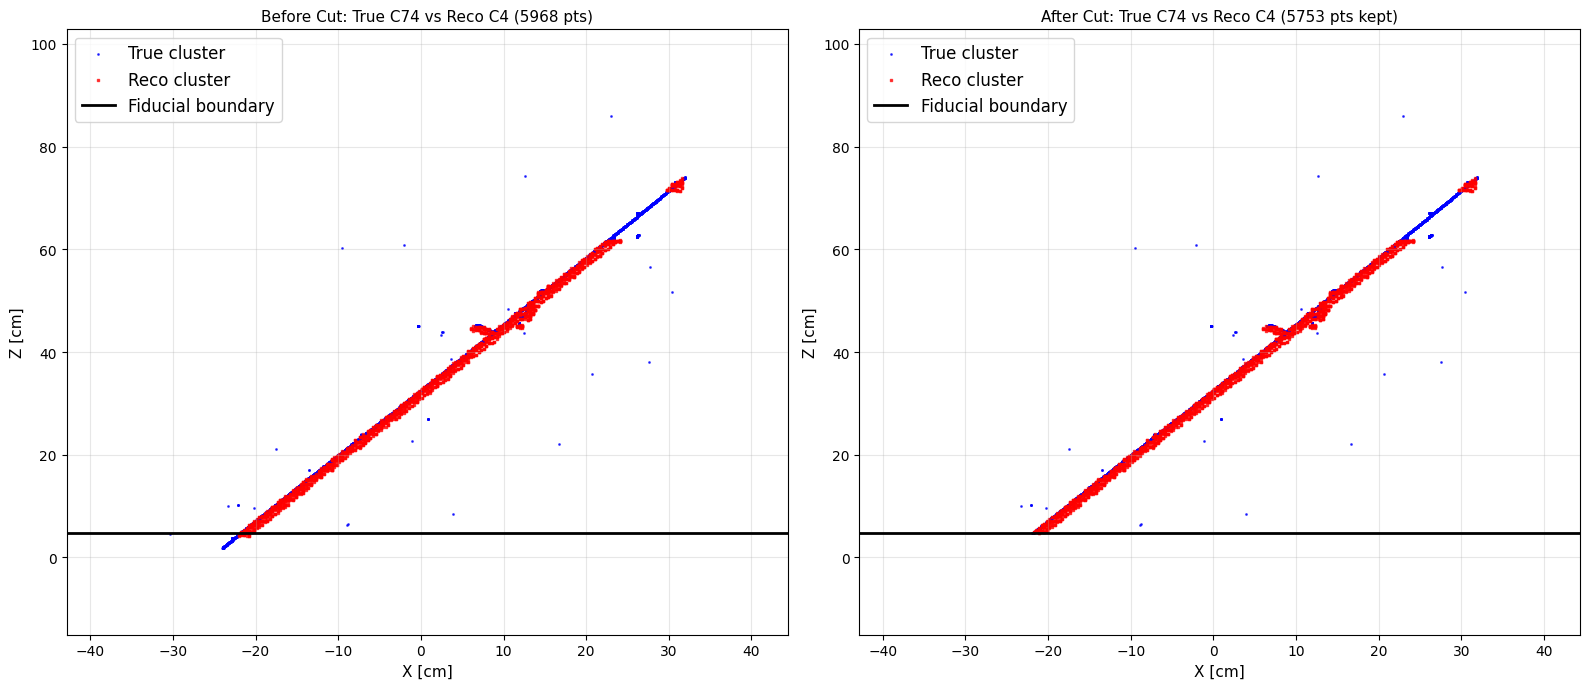

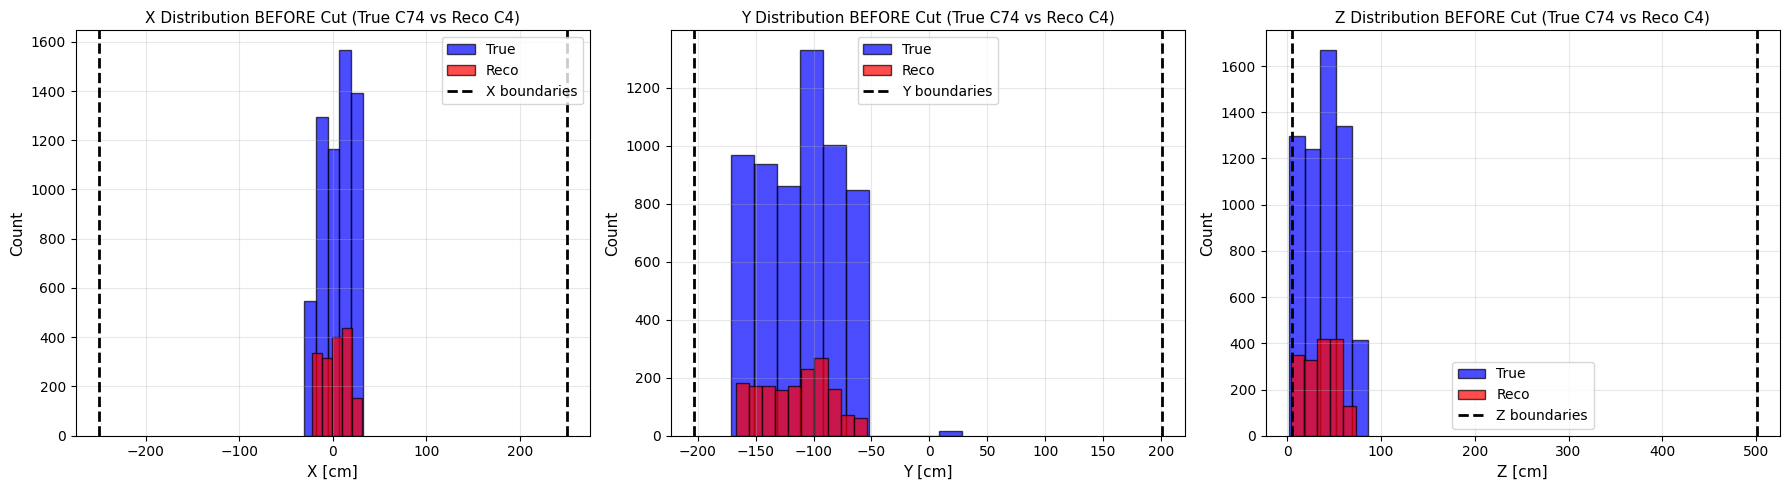

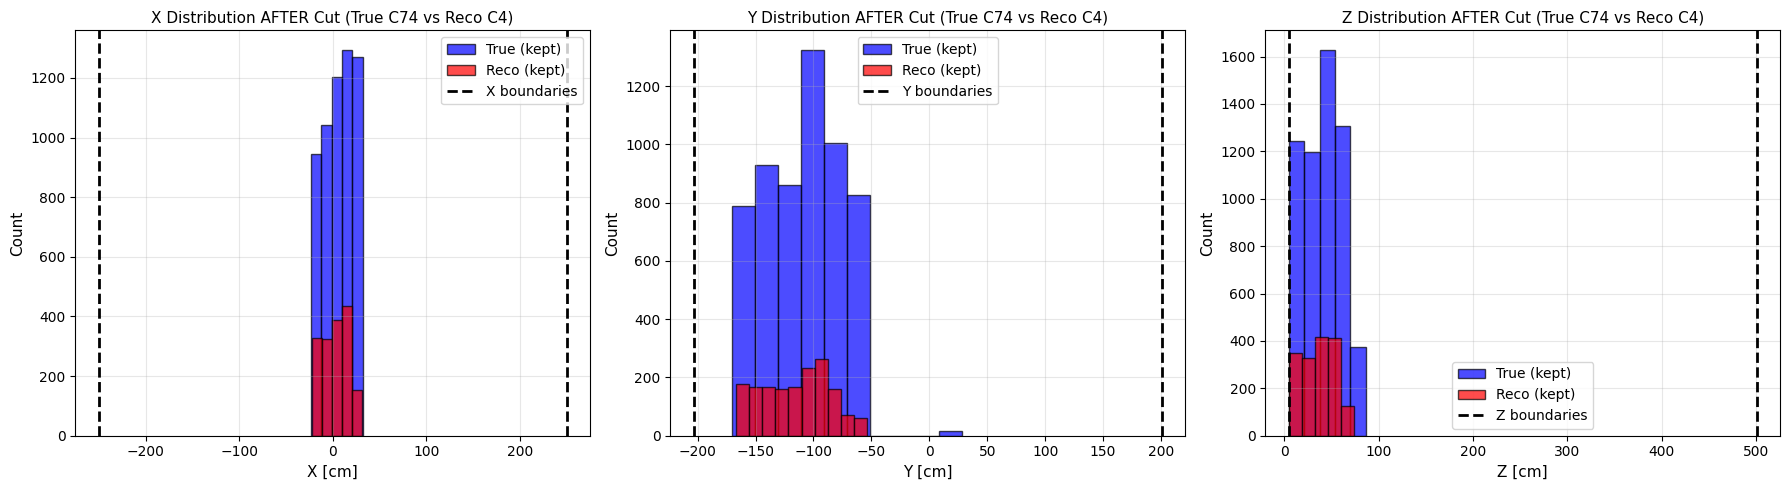


True Cluster 74 (Reco 4):
  True:  Total 5968, Kept: 5753, Removed: 215 (3.6%)
  Reco:  Total 1641, Kept: 1627, Removed: 14 (0.9%)


In [23]:
# Show visualization for true cluster 74 and its matching reco cluster

true_cluster_id = 74

# Get true cluster data
true_mask = evt_true_id == true_cluster_id
true_x = evt_true_x[true_mask]
true_y = evt_true_y[true_mask]
true_z = evt_true_z[true_mask]

if len(true_x) == 0:
    print(f"True cluster {true_cluster_id} not found!")
else:
    # Find matching reco cluster (most overlap)
    max_overlap = 0
    best_reco_id = None
    
    for reco_id in np.unique(evt_reco_id):
        reco_mask = evt_reco_id == reco_id
        reco_x_temp = evt_reco_x[reco_mask]
        reco_y_temp = evt_reco_y[reco_mask]
        reco_z_temp = evt_reco_z[reco_mask]
        
        if len(reco_x_temp) == 0 or len(true_x) == 0:
            continue
            
        true_pts = np.column_stack([true_x, true_y, true_z])
        reco_pts = np.column_stack([reco_x_temp, reco_y_temp, reco_z_temp])
        
        tree = KDTree(true_pts)
        distances, _ = tree.query(reco_pts, k=1)
        overlap = np.sum(distances < 2.0)
        
        if overlap > max_overlap:
            max_overlap = overlap
            best_reco_id = reco_id
    
    if best_reco_id is None:
        print(f"No matching reco cluster found for true cluster {true_cluster_id}")
    else:
        # Get matching reco cluster data
        reco_mask = evt_reco_id == best_reco_id
        reco_x = evt_reco_x[reco_mask]
        reco_y = evt_reco_y[reco_mask]
        reco_z = evt_reco_z[reco_mask]
        
        # Check which points are inside fiducial volume
        true_inside = is_inside_fiducial_volume(true_x, true_y, true_z, fiducial_volume)
        reco_inside = is_inside_fiducial_volume(reco_x, reco_y, reco_z, fiducial_volume)
        
        # Calculate zoom region based on ALL cluster points (true + reco)
        all_x = np.concatenate([true_x, reco_x])
        all_z = np.concatenate([true_z, reco_z])
        x_range = np.max(all_x) - np.min(all_x)
        z_range = np.max(all_z) - np.min(all_z)
        x_pad = x_range * 0.2
        z_pad = z_range * 0.2
        xlim = (np.min(all_x) - x_pad, np.max(all_x) + x_pad)
        zlim = (np.min(all_z) - z_pad, np.max(all_z) + z_pad)
        
        z_min = fiducial_volume['Z_min']
        z_max = fiducial_volume['Z_max']
        x_min = fiducial_volume['X_min']
        x_max = fiducial_volume['X_max']
        y_min = fiducial_volume['Y_min']
        y_max = fiducial_volume['Y_max']
        
        # ===== FIGURE 1: Spatial Before/After Comparison =====
        fig1, axes1 = plt.subplots(1, 2, figsize=(16, 7))
        
        # LEFT PLOT: Before fiducial cut
        ax_before = axes1[0]
        ax_before.scatter(true_x, true_z, s=1, alpha=0.7, c='blue', label='True cluster')
        ax_before.scatter(reco_x, reco_z, s=1, alpha=0.7, c='red', label='Reco cluster', marker='s')
        
        # Draw fiducial boundary
        rect_x = [x_min, x_max, x_max, x_min, x_min]
        rect_z = [z_min, z_min, z_max, z_max, z_min]
        ax_before.plot(rect_x, rect_z, 'k-', linewidth=2, label='Fiducial boundary')
        ax_before.set_xlim(xlim)
        ax_before.set_ylim(zlim)
        ax_before.set_xlabel('X [cm]', fontsize=11)
        ax_before.set_ylabel('Z [cm]', fontsize=11)
        ax_before.set_title(f'Before Cut: True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)} ({len(true_x)} pts)', fontsize=11)
        ax_before.grid(True, alpha=0.3)
        ax_before.legend(fontsize=12, loc='best')
        
        # RIGHT PLOT: After fiducial cut
        ax_after = axes1[1]
        ax_after.scatter(true_x[true_inside], true_z[true_inside], s=1, alpha=0.7, c='blue', label='True cluster')
        ax_after.scatter(reco_x[reco_inside], reco_z[reco_inside], s=1, alpha=0.7, c='red', label='Reco cluster', marker='s')
        ax_after.plot(rect_x, rect_z, 'k-', linewidth=2, label='Fiducial boundary')
        ax_after.set_xlim(xlim)
        ax_after.set_ylim(zlim)
        ax_after.set_xlabel('X [cm]', fontsize=11)
        ax_after.set_ylabel('Z [cm]', fontsize=11)
        ax_after.set_title(f'After Cut: True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)} ({np.sum(true_inside)} pts kept)', fontsize=11)
        ax_after.grid(True, alpha=0.3)
        ax_after.legend(fontsize=12, loc='best')
        
        plt.tight_layout()
        plt.show(block=False)
        
        # ===== FIGURE 2: Coordinate Distributions BEFORE Cuts =====
        fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
        
        # X Distribution (Before)
        nbins_x = 5
        nbins_y = 10
        nbins_z = 5
        ax_x = axes2[0]
        ax_x.hist(true_x, bins=nbins_x, alpha=0.7, label='True', color='blue', edgecolor='black')
        ax_x.hist(reco_x, bins=nbins_x, alpha=0.7, label='Reco', color='red', edgecolor='black')
        ax_x.axvline(x_min, color='black', linestyle='--', linewidth=2, label=f'X boundaries')
        ax_x.axvline(x_max, color='black', linestyle='--', linewidth=2)
        ax_x.set_xlabel('X [cm]', fontsize=11)
        ax_x.set_ylabel('Count', fontsize=11)
        ax_x.set_title(f'X Distribution BEFORE Cut (True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)})', fontsize=11)
        ax_x.legend(fontsize=10)
        ax_x.grid(True, alpha=0.3)
        
        # Y Distribution (Before)
        ax_y = axes2[1]
        ax_y.hist(true_y, bins=nbins_y, alpha=0.7, label='True', color='blue', edgecolor='black')
        ax_y.hist(reco_y, bins=nbins_y, alpha=0.7, label='Reco', color='red', edgecolor='black')
        ax_y.axvline(y_min, color='black', linestyle='--', linewidth=2, label=f'Y boundaries')
        ax_y.axvline(y_max, color='black', linestyle='--', linewidth=2)
        ax_y.set_xlabel('Y [cm]', fontsize=11)
        ax_y.set_ylabel('Count', fontsize=11)
        ax_y.set_title(f'Y Distribution BEFORE Cut (True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)})', fontsize=11)
        ax_y.legend(fontsize=10)
        ax_y.grid(True, alpha=0.3)
        
        # Z Distribution (Before)
        ax_z = axes2[2]
        ax_z.hist(true_z, bins=nbins_z, alpha=0.7, label='True', color='blue', edgecolor='black')
        ax_z.hist(reco_z, bins=nbins_z, alpha=0.7, label='Reco', color='red', edgecolor='black')
        ax_z.axvline(z_min, color='black', linestyle='--', linewidth=2, label=f'Z boundaries')
        ax_z.axvline(z_max, color='black', linestyle='--', linewidth=2)
        ax_z.set_xlabel('Z [cm]', fontsize=11)
        ax_z.set_ylabel('Count', fontsize=11)
        ax_z.set_title(f'Z Distribution BEFORE Cut (True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)})', fontsize=11)
        ax_z.legend(fontsize=10)
        ax_z.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show(block=False)
        
        # ===== FIGURE 3: Coordinate Distributions AFTER Cuts =====
        fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5))
        
        # X Distribution (After) - only kept points for both true and reco
        ax_x_after = axes3[0]
        ax_x_after.hist(true_x[true_inside], bins=nbins_x, alpha=0.7, label='True (kept)', color='blue', edgecolor='black')
        ax_x_after.hist(reco_x[reco_inside], bins=nbins_x, alpha=0.7, label='Reco (kept)', color='red', edgecolor='black')
        ax_x_after.axvline(x_min, color='black', linestyle='--', linewidth=2, label=f'X boundaries')
        ax_x_after.axvline(x_max, color='black', linestyle='--', linewidth=2)
        ax_x_after.set_xlabel('X [cm]', fontsize=11)
        ax_x_after.set_ylabel('Count', fontsize=11)
        ax_x_after.set_title(f'X Distribution AFTER Cut (True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)})', fontsize=11)
        ax_x_after.legend(fontsize=10)
        ax_x_after.grid(True, alpha=0.3)
        
        # Y Distribution (After) - only kept points for both true and reco
        ax_y_after = axes3[1]
        ax_y_after.hist(true_y[true_inside], bins=nbins_y, alpha=0.7, label='True (kept)', color='blue', edgecolor='black')
        ax_y_after.hist(reco_y[reco_inside], bins=nbins_y, alpha=0.7, label='Reco (kept)', color='red', edgecolor='black')
        ax_y_after.axvline(y_min, color='black', linestyle='--', linewidth=2, label=f'Y boundaries')
        ax_y_after.axvline(y_max, color='black', linestyle='--', linewidth=2)
        ax_y_after.set_xlabel('Y [cm]', fontsize=11)
        ax_y_after.set_ylabel('Count', fontsize=11)
        ax_y_after.set_title(f'Y Distribution AFTER Cut (True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)})', fontsize=11)
        ax_y_after.legend(fontsize=10)
        ax_y_after.grid(True, alpha=0.3)
        
        # Z Distribution (After) - only kept points for both true and reco
        ax_z_after = axes3[2]
        ax_z_after.hist(true_z[true_inside], bins=nbins_z, alpha=0.7, label='True (kept)', color='blue', edgecolor='black')
        ax_z_after.hist(reco_z[reco_inside], bins=nbins_z, alpha=0.7, label='Reco (kept)', color='red', edgecolor='black')
        ax_z_after.axvline(z_min, color='black', linestyle='--', linewidth=2, label=f'Z boundaries')
        ax_z_after.axvline(z_max, color='black', linestyle='--', linewidth=2)
        ax_z_after.set_xlabel('Z [cm]', fontsize=11)
        ax_z_after.set_ylabel('Count', fontsize=11)
        ax_z_after.set_title(f'Z Distribution AFTER Cut (True C{int(true_cluster_id)} vs Reco C{int(best_reco_id)})', fontsize=11)
        ax_z_after.legend(fontsize=10)
        ax_z_after.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show(block=False)
        
        n_total_true = len(true_x)
        n_kept_true = np.sum(true_inside)
        n_removed_true = n_total_true - n_kept_true
        
        n_total_reco = len(reco_x)
        n_kept_reco = np.sum(reco_inside)
        n_removed_reco = n_total_reco - n_kept_reco
        
        print(f"\nTrue Cluster {int(true_cluster_id)} (Reco {int(best_reco_id)}):")
        print(f"  True:  Total {n_total_true}, Kept: {n_kept_true}, Removed: {n_removed_true} ({100*n_removed_true/n_total_true:.1f}%)")
        print(f"  Reco:  Total {n_total_reco}, Kept: {n_kept_reco}, Removed: {n_removed_reco} ({100*n_removed_reco/n_total_reco:.1f}%)")
